--- Model 1: Multiple Linear Regression (Market + Sector) ---
const          -0.000324
Market (SPY)    0.100287
Tech (QQQ)      0.786293
dtype: float64
Adj. R-squared: 0.3573

--- Model 2: Non-Linear Regression (Treynor-Mazuy) ---
const           0.001701
Market (SPY)    1.061855
Market_Sq      -5.446915
dtype: float64
Adj. R-squared: 0.3478



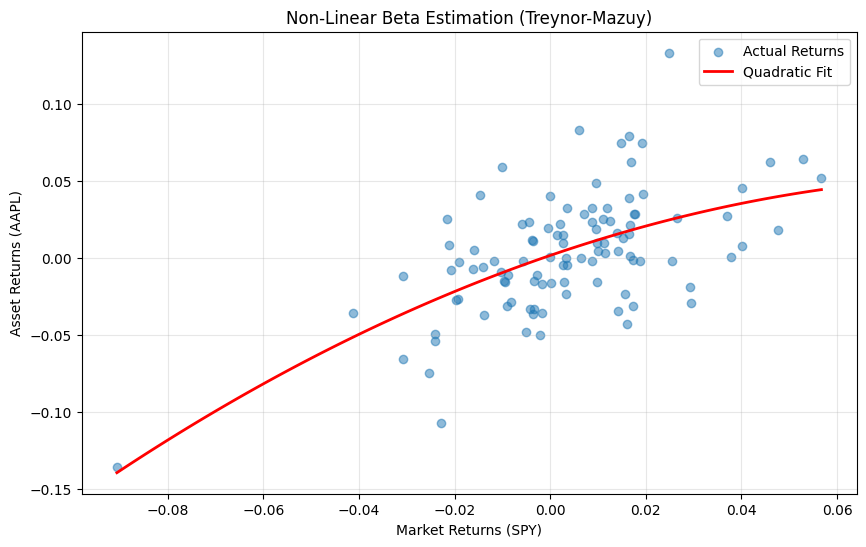

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Fetch Data
tickers = ['AAPL', 'SPY', 'QQQ']

# Toggle between 5-year monthly and 2-year weekly data
USE_5Y_MONTHLY = False
if USE_5Y_MONTHLY:
    period = '5y'
    interval = '1mo'
else:
    period = '2y'
    interval = '1wk'

data = yf.download(tickers, period=period, interval=interval, progress=False)['Close']

# 2. Calculate Period Returns (Drop NaN)
returns = data.pct_change().dropna()

y = returns['AAPL']
x_mkt = returns['SPY']
x_sector = returns['QQQ']

# --- Model 1: Multiple Linear Regression (Two-Factor) ---
# Factors: Market (SPY) + Tech Sector (QQQ)
X_multi = pd.DataFrame({'Market (SPY)': x_mkt, 'Tech (QQQ)': x_sector})
X_multi = sm.add_constant(X_multi)

model_multi = sm.OLS(y, X_multi).fit()

# --- Model 2: Non-Linear Regression (Quadratic) ---
# Factors: Market (SPY) + Market Squared (Convexity)
X_nonlinear = pd.DataFrame({
    'Market (SPY)': x_mkt,
    'Market_Sq': x_mkt ** 2
})
X_nonlinear = sm.add_constant(X_nonlinear)

model_nonlinear = sm.OLS(y, X_nonlinear).fit()

# --- Output Results ---
print("--- Model 1: Multiple Linear Regression (Market + Sector) ---")
print(model_multi.params)
print(f"Adj. R-squared: {model_multi.rsquared_adj:.4f}\n")

print("--- Model 2: Non-Linear Regression (Treynor-Mazuy) ---")
print(model_nonlinear.params)
print(f"Adj. R-squared: {model_nonlinear.rsquared_adj:.4f}\n")

# Visualization of Non-Linear Fit
plt.figure(figsize=(10, 6))
plt.scatter(x_mkt, y, alpha=0.5, label='Actual Returns')

# Generate smooth line for prediction
x_range = np.linspace(x_mkt.min(), x_mkt.max(), 100)
y_pred = model_nonlinear.params['const'] + \
         model_nonlinear.params['Market (SPY)'] * x_range + \
         model_nonlinear.params['Market_Sq'] * (x_range ** 2)

plt.plot(x_range, y_pred, color='red', linewidth=2, label='Quadratic Fit')
plt.xlabel('Market Returns (SPY)')
plt.ylabel('Asset Returns (AAPL)')
plt.title('Non-Linear Beta Estimation (Treynor-Mazuy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()